# Nighttime Lights in Lebanon (2026)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

import altair as alt
import attaviz

attaviz.enable()  # every chart now uses the WBG theme

In [3]:
ntl_adm0_monthly = pd.read_csv(
    "../../data/ntl/aggregated/monthly/ntl_lbn_adm0_monthly.csv"
)
ntl_adm1_monthly = pd.read_csv(
    "../../data/ntl/aggregated/monthly/ntl_lbn_adm1_monthly.csv"
)
ntl_adm2_monthly = pd.read_csv(
    "../../data/ntl/aggregated/monthly/ntl_lbn_adm2_monthly.csv"
)
ntl_adm3_monthly = pd.read_csv(
    "../../data/ntl/aggregated/monthly/ntl_lbn_adm3_monthly.csv"
)

ntl_adm0_annual = pd.read_csv(
    "../../data/ntl/aggregated/annual/ntl_lbn_adm0_annual.csv"
)
ntl_adm1_annual = pd.read_csv(
    "../../data/ntl/aggregated/annual/ntl_lbn_adm1_annual.csv"
)
ntl_adm2_annual = pd.read_csv(
    "../../data/ntl/aggregated/annual/ntl_lbn_adm2_annual.csv"
)
ntl_adm3_annual = pd.read_csv(
    "../../data/ntl/aggregated/annual/ntl_lbn_adm3_annual.csv"
)

In [78]:
attaviz.enable(size="large")

chart = (
    alt.Chart(ntl_adm0_annual)
    .mark_bar()
    .encode(
        x=alt.X("date:T", timeUnit="year", title="Year"),
        y="ntl_sum:Q",
    )
    .properties(
        width=600,
        height=394,
        title=alt.TitleParams(
            text="Annual Nighttime Lights in Lebanon (2012–2025)",
            subtitle="Sum of nighttime light radiance (VNP46A4)",
        ),
    )
)

chart_with_caption = attaviz.add_caption(
    chart, "Source: NASA Black Marble (VNP46A4). Accessed: April 2026."
)
chart_with_caption.show()

alt.VConcatChart(...)

Light went up in 2025 compared to the previous year in Lebanon. 

In [79]:
attaviz.enable(size="large")

_df = ntl_adm0_monthly[ntl_adm0_monthly["date"] >= "2021-01-01"].copy()
_df["year_month"] = pd.to_datetime(_df["date"]).dt.strftime("%b %Y")
_df["date_order"] = pd.to_datetime(_df["date"])

_sorted_labels = _df.sort_values("date_order")["year_month"].tolist()
_every_sixth = _sorted_labels[::6]

chart = (
    alt.Chart(_df)
    .mark_bar()
    .encode(
        x=alt.X(
            "year_month:N",
            sort=alt.EncodingSortField(field="date_order", order="ascending"),
            title="Month",
            axis=alt.Axis(values=_every_sixth, labelAngle=-45),
        ),
        y="ntl_sum:Q",
        tooltip=[
            alt.Tooltip("year_month:N", title="Month"),
            alt.Tooltip("ntl_sum:Q", title="NTL Sum"),
        ],
    )
    .properties(
        width=600,
        height=394,
        title=alt.TitleParams(
            text="Monthly Nighttime Lights in Lebanon (2021–2026)",
            subtitle="Sum of nighttime light radiance",
        ),
    )
)

chart_with_caption = attaviz.add_caption(
    chart, "Source: NASA Black Marble (VNP46A3). Accessed: April 2026."
)
chart_with_caption.show()

alt.VConcatChart(...)

In 2026, there was a reduction in light in March 2026 compared to February 2026. 

In [80]:
attaviz.enable()

_df1 = ntl_adm1_monthly[
    (ntl_adm1_monthly["date"] >= "2025-01-01")
    & (ntl_adm1_monthly["date"] <= "2026-03-01")
].copy()
_df1["year_month"] = pd.to_datetime(_df1["date"]).dt.strftime("%b %Y")
_df1["date_order"] = pd.to_datetime(_df1["date"])

chart = (
    alt.Chart(_df1)
    .mark_bar()
    .encode(
        x=alt.X(
            "year_month:N",
            sort=alt.EncodingSortField(field="date_order", order="ascending"),
            title=None,
            axis=alt.Axis(labelAngle=-45, labelFontSize=9),
        ),
        y=alt.Y("ntl_sum:Q", title="NTL Sum"),
        tooltip=[
            alt.Tooltip("adm1_name:N", title="Governorate"),
            alt.Tooltip("year_month:N", title="Month"),
            alt.Tooltip("ntl_sum:Q", title="NTL Sum"),
        ],
    )
    .properties(
        width=150,
        height=150,
    )
    .facet(
        facet=alt.Facet(
            "adm1_name:N",
            title=None,
            header=alt.Header(
                titleFontSize=11, labelFontSize=11, labelFontWeight="bold"
            ),
        ),
        columns=3,
        title=alt.TitleParams(
            text="Monthly Nighttime Lights by Governorate (Jan 2025 – Mar 2026)",
            subtitle="Sum of nighttime light radiance",
        ),
    )
    .resolve_scale(x="independent", y="independent")
)

chart_with_caption = attaviz.add_caption(
    chart, "Source: NASA Black Marble (VNP46A3). Accessed: April 2026."
)
chart_with_caption.show()

alt.VConcatChart(...)

Although Beirut didn't see lower lights, there is a significant drop in nightlights in all other regions. The significant spike in June 2025 could potentially be an issue with the data, and we're still looking into that. 

In [39]:
lbn_adm0 = gpd.read_file(
    "../../data/shapefiles/lbn_admin_boundaries.shp/lbn_admin0.shp"
)
lbn_adm1 = gpd.read_file(
    "../../data/shapefiles/lbn_admin_boundaries.shp/lbn_admin1.shp"
)
lbn_adm2 = gpd.read_file(
    "../../data/shapefiles/lbn_admin_boundaries.shp/lbn_admin2.shp"
)
lbn_adm3 = gpd.read_file(
    "../../data/shapefiles/lbn_admin_boundaries.shp/lbn_admin3.shp"
)

In [43]:
lbn_ntl_monthly_adm1 = pd.merge(
    ntl_adm1_monthly, lbn_adm1, left_on="adm1_pcode", right_on="adm1_pcode"
)

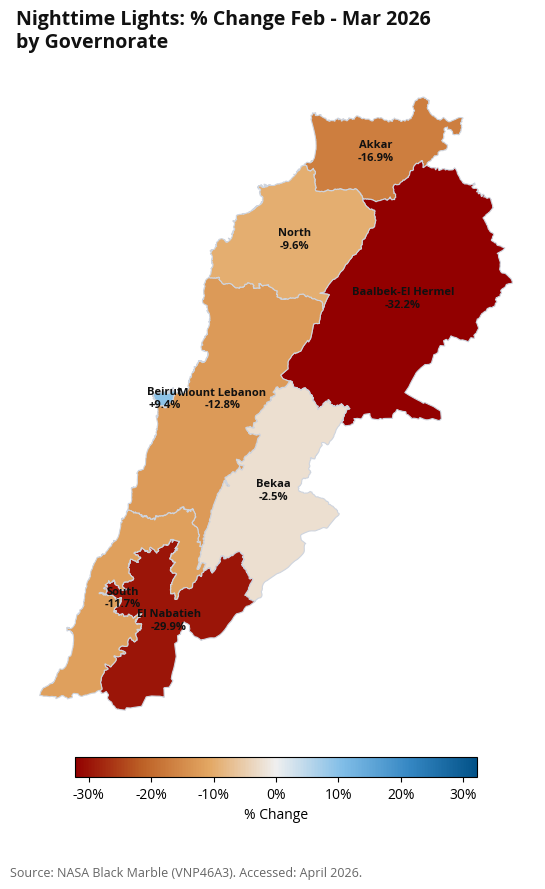

In [47]:
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import attaviz.colors as wbg

plt.rcParams["font.family"] = "Open Sans"
plt.rcParams["font.weight"] = "400"
plt.rcParams["text.color"] = wbg.TEXT

# WBG diverging palette (negative=red, mid=grey, positive=blue)
wbg_div = LinearSegmentedColormap.from_list("wbg_div", wbg.DIV_DEFAULT, N=256)

_feb = lbn_ntl_monthly_adm1[lbn_ntl_monthly_adm1["date"] == "2026-02-01"][
    ["adm1_pcode", "adm1_name_x", "ntl_sum", "geometry"]
].copy()
_mar = lbn_ntl_monthly_adm1[lbn_ntl_monthly_adm1["date"] == "2026-03-01"][
    ["adm1_pcode", "ntl_sum"]
].copy()

_diff = _feb.merge(_mar, on="adm1_pcode", suffixes=("_feb", "_mar"))
_diff["pct_change"] = (
    (_diff["ntl_sum_mar"] - _diff["ntl_sum_feb"]) / _diff["ntl_sum_feb"] * 100
)
_gdf = gpd.GeoDataFrame(_diff, geometry="geometry", crs=lbn_adm1.crs)

fig, ax = plt.subplots(1, 1, figsize=(7, 9))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

vmax = max(abs(_gdf["pct_change"].min()), abs(_gdf["pct_change"].max()))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

_gdf.plot(
    column="pct_change",
    ax=ax,
    cmap=wbg_div,
    norm=norm,
    edgecolor=wbg.GREY_200,
    linewidth=0.8,
    legend=True,
    legend_kwds={
        "label": "% Change",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.02,
        "format": "%.0f%%",
    },
)

for _, row in _gdf.iterrows():
    centroid = row["geometry"].centroid
    ax.annotate(
        f"{row['adm1_name_x']}\n{row['pct_change']:+.1f}%",
        xy=(centroid.x, centroid.y),
        ha="center",
        va="center",
        fontsize=8,
        fontfamily="Open Sans",
        color=wbg.TEXT,
        fontweight="600",
    )

ax.set_axis_off()
ax.set_title(
    "Nighttime Lights: % Change Feb - Mar 2026\nby Governorate",
    fontsize=14,
    fontweight="700",
    pad=14,
    color=wbg.TEXT,
    loc="left",
    fontfamily="Open Sans",
)
fig.text(
    0.12,
    0.02,
    "Source: NASA Black Marble (VNP46A3). Accessed: April 2026.",
    ha="left",
    fontsize=9,
    color=wbg.TEXT_SUBTLE,
    fontfamily="Open Sans",
)
plt.tight_layout()
plt.show()

In [65]:
_beirut_adm3 = lbn_adm3[lbn_adm3["adm1_name"] == "Beirut"].copy()
_beirut_adm3["adm3_pcode"] = _beirut_adm3["adm3_pcode"].astype(int)

lbn_ntl_monthly_adm3 = pd.merge(
    ntl_adm3_monthly, _beirut_adm3, left_on="adm3_pcode", right_on="adm3_pcode"
)

_feb3 = lbn_ntl_monthly_adm3[lbn_ntl_monthly_adm3["date"] == "2026-02-01"][
    ["adm3_pcode", "adm3_name_x", "ntl_sum", "geometry"]
].copy()
_mar3 = lbn_ntl_monthly_adm3[lbn_ntl_monthly_adm3["date"] == "2026-03-01"][
    ["adm3_pcode", "ntl_sum"]
].copy()

_diff3 = _feb3.merge(_mar3, on="adm3_pcode", suffixes=("_feb", "_mar"))
_diff3["pct_change"] = (
    (_diff3["ntl_sum_mar"] - _diff3["ntl_sum_feb"]) / _diff3["ntl_sum_feb"] * 100
)
_gdf3 = gpd.GeoDataFrame(_diff3, geometry="geometry", crs=_beirut_adm3.crs)

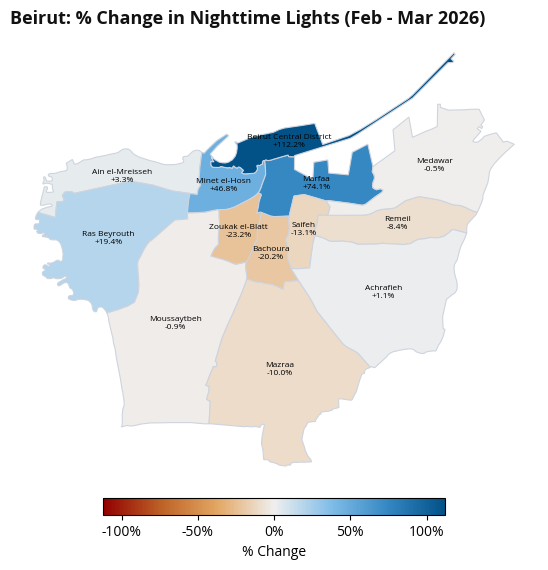

In [76]:
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import attaviz.colors as wbg

wbg_div = LinearSegmentedColormap.from_list("wbg_div", wbg.DIV_DEFAULT, N=256)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

vmax = max(abs(_gdf3["pct_change"].min()), abs(_gdf3["pct_change"].max()))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

_gdf3.plot(
    column="pct_change",
    ax=ax,
    cmap=wbg_div,
    norm=norm,
    edgecolor=wbg.GREY_200,
    linewidth=0.8,
    legend=True,
    legend_kwds={
        "label": "% Change",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.02,
        "format": "%.0f%%",
    },
)

for _, row in _gdf3.iterrows():
    centroid = row["geometry"].centroid
    ax.annotate(
        f"{row['adm3_name_x']}\n{row['pct_change']:+.1f}%",
        xy=(centroid.x, centroid.y),
        ha="center",
        va="center",
        fontsize=6,
        fontweight="normal",
        color="black",
    )

ax.set_axis_off()
ax.set_title(
    "Beirut: % Change in Nighttime Lights (Feb - Mar 2026)",
    loc="left",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()